## Homework 4
MSDS 604 Time Series Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import itertools
import warnings
import os

warnings.filterwarnings('ignore')
os.chdir('/Users/tomas/Documents/2.3_USF MSDS/MSDS604/hw4')

### Setup & Data Loading

In [2]:
# Load the data
df = pd.read_csv('profit.csv')

# Per instructions, use index 0-196 as history, and the rest as test data
history_data = df.loc[0:196, 'Profit'].copy()
test_data = df.loc[197:199, 'Profit'].copy()

print(f"History data length: {len(history_data)}")
print(f"Test data length: {len(test_data)}")

History data length: 197
Test data length: 3


### Question 1: Method 1 (Direct Multistep Forecasting)

In [3]:
def cv_method1(y, p_values, q_values, min_fold_length=3, max_fold_length=3, num_folds=5):
    """
    5-Fold Cross Validation for Method 1 (Direct Multistep Forecasting).
    The fold_length dictates how many observations are held out for validation.
    This parameter can be tuned via grid search by adjusting min/max bounds.
    """
    results = []
    n = len(y)
    
    print(f"Running Method 1 CV (Direct Multistep Forecasting)with {num_folds} folds...")
    for p, q in itertools.product(p_values, q_values):
        for fold_length in range(min_fold_length, max_fold_length + 1):
            try:
                rmse_lists = {step: [] for step in range(1, fold_length + 1)}
                
                for i in range(num_folds):
                    # Expanding window logic ensures we use sequential folds at the end of the history
                    train_end = n - num_folds * fold_length + i * fold_length
                    train_y = y.iloc[:train_end]
                    val_y = y.iloc[train_end : train_end + fold_length]
                    
                    # Method 1: fit once on train_y
                    model = ARIMA(train_y, order=(p, 0, q))
                    model_fit = model.fit()
                    
                    # Direct multi-step forecast
                    forecast = model_fit.forecast(steps=fold_length)
                    
                    # Calculate error for each step predicted
                    for step in range(fold_length):
                        rmse_lists[step+1].append((val_y.iloc[step] - forecast.iloc[step])**2)
                        
                # Calculate Average RMSE across folds for each step
                step_rmses = {}
                for step in range(1, fold_length + 1):
                    step_rmses[f'{step}-step'] = np.sqrt(np.mean(rmse_lists[step]))
                
                # Overall 3-step average metric
                avg_rmse = np.mean(list(step_rmses.values()))
                
                res_dict = {'p': p, 'q': q, 'fold_length': fold_length, 'avg of 3 steps': avg_rmse}
                res_dict.update(step_rmses)
                
                results.append(res_dict)
            except Exception as e:
                continue
                
    return pd.DataFrame(results)

# Search ranges (max p,q = 5)
p_values = range(0, 6)
q_values = range(0, 6)

results_m1 = cv_method1(history_data, p_values, q_values, min_fold_length=3, max_fold_length=3, num_folds=5)

Running Method 1 CV (Direct Multistep Forecasting)with 5 folds...


In [4]:
results_m1

,p,q,fold_length,avg of 3 steps,1-step,2-step,3-step
0,0,0,3,0.825266,0.853688,0.698734,0.923377
1,0,1,3,0.985715,1.337288,0.701990,0.917868
2,0,2,3,1.034995,1.241005,0.949057,0.914922
3,0,3,3,0.961249,1.141197,0.952242,0.790308
4,0,4,3,0.931143,1.123846,0.934335,0.735249
5,0,5,3,1.070265,1.335429,1.008801,0.866565
6,1,0,3,1.118265,1.244601,0.906496,1.203698
7,1,1,3,1.117110,1.239465,0.903513,1.208352
8,1,2,3,1.123053,1.238070,0.973491,1.157599
9,1,3,3,1.108310,1.208507,0.966337,1.150086


In [5]:
# Find best models and construct the required table
metrics = ['1-step', '2-step', '3-step', 'avg of 3 steps']
best_rmses = []
best_models = []

for m in metrics:
    best_row = results_m1.loc[results_m1[m].idxmin()]
    best_rmses.append(f"{best_row[m]:.4f}")
    best_models.append(f"({int(best_row['p'])},{int(best_row['q'])})")

table_m1 = pd.DataFrame({
    '1-step': [best_rmses[0], best_models[0]],
    '2-step': [best_rmses[1], best_models[1]],
    '3-step': [best_rmses[2], best_models[2]],
    'avg of 3 steps': [best_rmses[3], best_models[3]]
}, index=['Best-RMSE', 'Best-Model (p,q)'])

print("Method 1 Results:")
display(table_m1)

Method 1 Results:


,1-step,2-step,3-step,avg of 3 steps
Best-RMSE,0.8537,0.6987,0.7352,0.8253
"Best-Model (p,q)","(0,0)","(0,0)","(0,4)","(0,0)"


### Question 2: Method 2 (Recursive Forecasting)

In [6]:
def cv_method2(y, p_values, q_values, min_fold_length=3, max_fold_length=3, num_folds=5):
    """
    5-Fold Cross Validation for Method 2 (Recursive Forecasting).
    Strictly follows instructions to completely re-fit the model from scratch 
    after appending each new prediction.
    """
    results = []
    n = len(y)
    
    print(f"Running Method 2 CV (Recursive Forecasting) with {num_folds} folds. This may take a moment...")
    for p, q in itertools.product(p_values, q_values):
        for fold_length in range(min_fold_length, max_fold_length + 1):
            try:
                rmse_lists = {step: [] for step in range(1, fold_length + 1)}
                
                for i in range(num_folds):
                    train_end = n - num_folds * fold_length + i * fold_length
                    
                    # Using a list allows for easy appending of recursive forecasts
                    train_y = list(y.iloc[:train_end])
                    val_y = y.iloc[train_end : train_end + fold_length]
                    
                    forecasts = []
                    # Method 2: recursive forecasting loop
                    for step in range(fold_length):
                        # Refitting the model completely for every step
                        model = ARIMA(train_y, order=(p, 0, q))
                        model_fit = model.fit()
                        
                        # Predict 1 step ahead
                        pred = model_fit.forecast(steps=1)
                        pred_val = pred.iloc[0] if isinstance(pred, pd.Series) else pred[0]
                            
                        forecasts.append(pred_val)
                        
                        # Append prediction to train_y for the next iteration's fit
                        train_y.append(pred_val)
                    
                    for step in range(fold_length):
                        rmse_lists[step+1].append((val_y.iloc[step] - forecasts[step])**2)
                        
                step_rmses = {}
                for step in range(1, fold_length + 1):
                    step_rmses[f'{step}-step'] = np.sqrt(np.mean(rmse_lists[step]))
                
                avg_rmse = np.mean(list(step_rmses.values()))
                
                res_dict = {'p': p, 'q': q, 'fold_length': fold_length, 'avg of 3 steps': avg_rmse}
                res_dict.update(step_rmses)
                
                results.append(res_dict)
            except Exception as e:
                continue
                
    return pd.DataFrame(results)

results_m2 = cv_method2(history_data, p_values, q_values, min_fold_length=3, max_fold_length=3, num_folds=5)

Running Method 2 CV (Recursive Forecasting) with 5 folds. This may take a moment...


In [7]:
best_rmses_m2 = []
best_models_m2 = []

for m in metrics:
    best_row = results_m2.loc[results_m2[m].idxmin()]
    best_rmses_m2.append(f"{best_row[m]:.4f}")
    best_models_m2.append(f"({int(best_row['p'])},{int(best_row['q'])})")

table_m2 = pd.DataFrame({
    '1-step': [best_rmses_m2[0], best_models_m2[0]],
    '2-step': [best_rmses_m2[1], best_models_m2[1]],
    '3-step': [best_rmses_m2[2], best_models_m2[2]],
    'avg of 3 steps': [best_rmses_m2[3], best_models_m2[3]]
}, index=['Best-RMSE', 'Best-Model (p,q)'])

print("Method 2 Results:")
display(table_m2)

Method 2 Results:


,1-step,2-step,3-step,avg of 3 steps
Best-RMSE,0.8537,0.6987,0.7352,0.8253
"Best-Model (p,q)","(0,0)","(0,0)","(0,4)","(0,0)"


### Question 3: Final Forecasts and Plotting

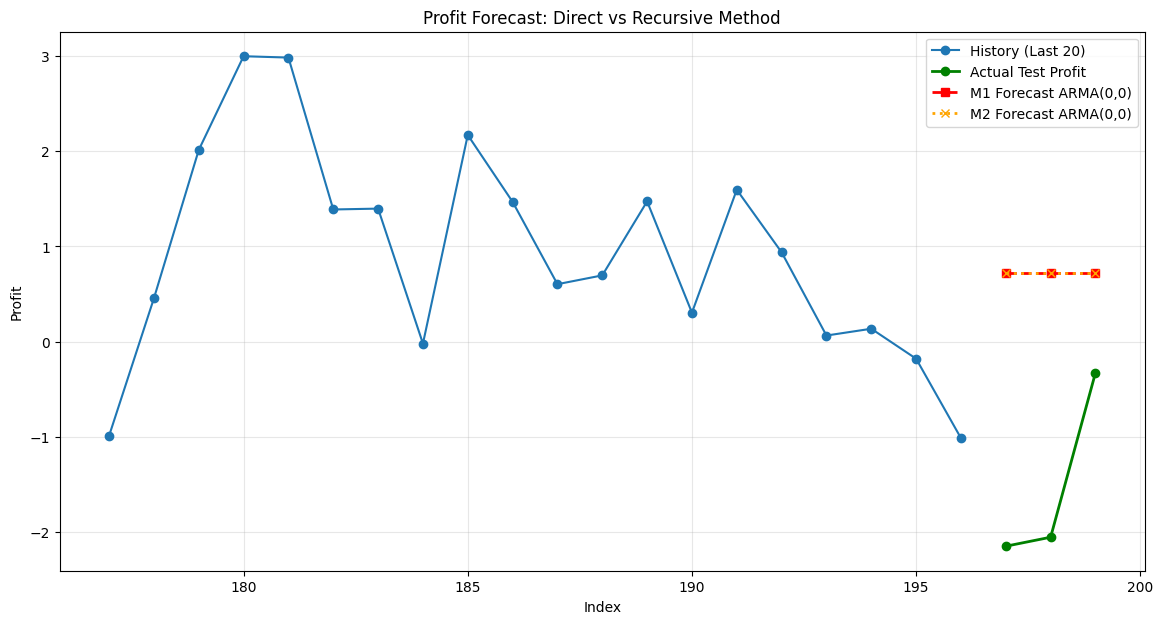


Test Set RMSE Evaluation:


,1-step,2-step,3-step,avg of 3 steps
"Method 1 (p=0, q=0)",2.8695,2.7749,1.0486,2.2310
"Method 2 (p=0, q=0)",2.8695,2.7749,1.0486,2.2310


In [8]:
# Get the overall best models from the 'avg of 3 steps' logic
best_m1_overall = results_m1.loc[results_m1['avg of 3 steps'].idxmin()]
best_m2_overall = results_m2.loc[results_m2['avg of 3 steps'].idxmin()]

# 1. Refit Method 1 Best Model
p1, q1 = int(best_m1_overall['p']), int(best_m1_overall['q'])
model1 = ARIMA(history_data, order=(p1, 0, q1))
model1_fit = model1.fit()
forecast_m1 = model1_fit.forecast(steps=3)
forecast_m1.index = test_data.index

# 2. Refit Method 2 Best Model
p2, q2 = int(best_m2_overall['p']), int(best_m2_overall['q'])
train_y_m2 = list(history_data)
forecast_m2 = []
for step in range(3):
    model2 = ARIMA(train_y_m2, order=(p2, 0, q2))
    model2_fit = model2.fit()
    pred = model2_fit.forecast(steps=1)
    pred_val = pred.iloc[0] if isinstance(pred, pd.Series) else pred[0]
    forecast_m2.append(pred_val)
    train_y_m2.append(pred_val)

forecast_m2 = pd.Series(forecast_m2, index=test_data.index)

# 3. Visual Comparison
plt.figure(figsize=(14, 7))

# Plot last 20 values of history
plt.plot(history_data.index[-20:], history_data.tail(20), label='History (Last 20)', color='#1f77b4', marker='o')

# Plot Actual Test Data
plt.plot(test_data.index, test_data, label='Actual Test Profit', color='green', marker='o', linewidth=2)

# Plot Method 1 Forecast
plt.plot(forecast_m1.index, forecast_m1, label=f'M1 Forecast ARMA({p1},{q1})', color='red', linestyle='--', marker='s', linewidth=2)

# Plot Method 2 Forecast
plt.plot(forecast_m2.index, forecast_m2, label=f'M2 Forecast ARMA({p2},{q2})', color='orange', linestyle=':', marker='x', linewidth=2)

plt.title('Profit Forecast: Direct vs Recursive Method')
plt.xlabel('Index')
plt.ylabel('Profit')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- 4. Test Set Evaluation Table ---

# Calculate RMSE for each step for Method 1
m1_rmse_1 = np.sqrt((test_data.iloc[0] - forecast_m1.iloc[0])**2)
m1_rmse_2 = np.sqrt((test_data.iloc[1] - forecast_m1.iloc[1])**2)
m1_rmse_3 = np.sqrt((test_data.iloc[2] - forecast_m1.iloc[2])**2)
m1_avg_rmse = np.mean([m1_rmse_1, m1_rmse_2, m1_rmse_3])

# Calculate RMSE for each step for Method 2
m2_rmse_1 = np.sqrt((test_data.iloc[0] - forecast_m2.iloc[0])**2)
m2_rmse_2 = np.sqrt((test_data.iloc[1] - forecast_m2.iloc[1])**2)
m2_rmse_3 = np.sqrt((test_data.iloc[2] - forecast_m2.iloc[2])**2)
m2_avg_rmse = np.mean([m2_rmse_1, m2_rmse_2, m2_rmse_3])

# Create and display the table
test_results = pd.DataFrame({
    '1-step': [f"{m1_rmse_1:.4f}", f"{m2_rmse_1:.4f}"],
    '2-step': [f"{m1_rmse_2:.4f}", f"{m2_rmse_2:.4f}"],
    '3-step': [f"{m1_rmse_3:.4f}", f"{m2_rmse_3:.4f}"],
    'avg of 3 steps': [f"{m1_avg_rmse:.4f}", f"{m2_avg_rmse:.4f}"]
}, index=[f'Method 1 (p={p1}, q={q1})', f'Method 2 (p={p2}, q={q2})'])

print("\nTest Set RMSE Evaluation:")
display(test_results)